In [2]:
import pandas as pd
import numpy as np

df = pd.read_excel("hr_employee_data.xlsx")

print(df.shape)
print(df.head())
print(df.info())
print(df.isna().sum())
print(df["left"].value_counts())
print(df["left"].value_counts(normalize=True))

(14999, 11)
     Emp_Id  satisfaction_level  last_evaluation  number_project  \
0  IND02438                0.38             0.53               2   
1  IND28133                0.80             0.86               5   
2  IND07164                0.11             0.88               7   
3  IND30478                0.72             0.87               5   
4  IND24003                0.37             0.52               2   

   average_montly_hours  time_spend_company  Work_accident  left  \
0                   157                   3              0     1   
1                   262                   6              0     1   
2                   272                   4              0     1   
3                   223                   5              0     1   
4                   159                   3              0     1   

   promotion_last_5years Department  salary  
0                      0      sales     low  
1                      0      sales  medium  
2                      0      sa

In [3]:
X = df.drop(columns=["left", "Emp_Id"])
y = df["left"]

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
numeric_features = [
    "satisfaction_level",
    "last_evaluation",
    "number_project",
    "average_montly_hours",
    "time_spend_company",
    "Work_accident",
    "promotion_last_5years"
]

In [6]:
categorical_features = [
    "Department",
    "salary"
]

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logreg = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

logreg.fit(X_train, y_train)

y_pred_logreg = logreg.predict(X_test)

In [9]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_logreg))

              precision    recall  f1-score   support

           0       0.82      0.93      0.87      2286
           1       0.62      0.35      0.45       714

    accuracy                           0.79      3000
   macro avg       0.72      0.64      0.66      3000
weighted avg       0.77      0.79      0.77      3000



In [10]:
from sklearn.ensemble import RandomForestClassifier

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

random_forest = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)

In [11]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2286
           1       0.99      0.96      0.98       714

    accuracy                           0.99      3000
   macro avg       0.99      0.98      0.99      3000
weighted avg       0.99      0.99      0.99      3000



In [12]:
from sklearn.ensemble import ExtraTreesClassifier

extra_trees = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        ("classifier", ExtraTreesClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

extra_trees.fit(X_train, y_train)

y_pred_et = extra_trees.predict(X_test)

print(classification_report(y_test, y_pred_et))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2286
           1       0.99      0.96      0.97       714

    accuracy                           0.99      3000
   macro avg       0.99      0.98      0.98      3000
weighted avg       0.99      0.99      0.99      3000



In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": logreg,
    "Random Forest": random_forest,
    "Extra Trees": extra_trees
}

for name, model in models.items():
    y_pred = model.predict(X_test)

    print(name)
    print("Accuracy :", round(accuracy_score(y_test, y_pred), 3))
    print("Precision:", round(precision_score(y_test, y_pred), 3))
    print("Recall   :", round(recall_score(y_test, y_pred), 3))
    print("F1-score :", round(f1_score(y_test, y_pred), 3))
    print()

Logistic Regression
Accuracy : 0.794
Precision: 0.616
Recall   : 0.353
F1-score : 0.449

Random Forest
Accuracy : 0.99
Precision: 0.994
Recall   : 0.964
F1-score : 0.979

Extra Trees
Accuracy : 0.988
Precision: 0.986
Recall   : 0.964
F1-score : 0.975



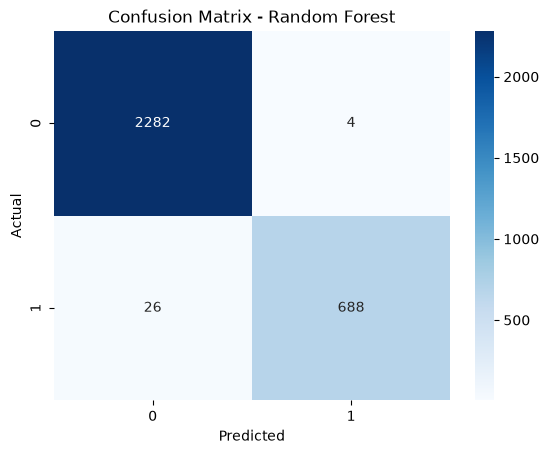

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [15]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    random_forest,
    param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(grid_search.best_params_)
print(grid_search.best_score_)

{'classifier__max_depth': 20, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 100}
0.9761401103860615


In [16]:
best_model = grid_search.best_estimator_

feature_names = (
    best_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = (
    best_model
    .named_steps["classifier"]
    .feature_importances_
)

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print(feature_importance.head(10))

                      feature  importance
0     num__satisfaction_level    0.311930
4     num__time_spend_company    0.180797
2         num__number_project    0.172296
3   num__average_montly_hours    0.160396
1        num__last_evaluation    0.126092
5          num__Work_accident    0.011165
18            cat__salary_low    0.006729
17           cat__salary_high    0.004899
16  cat__Department_technical    0.003555
14      cat__Department_sales    0.003366


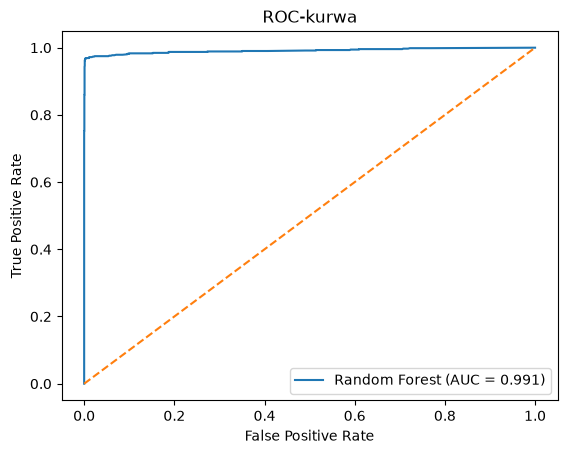

ROC-AUC: 0.9912271995412338


In [18]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-kurwa")
plt.legend()
plt.show()

print("ROC-AUC:", auc)